In [1]:
import joblib
import json
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

best_model = joblib.load("../models/best_model.joblib")
preprocessor = joblib.load("../models/preprocessor.joblib")

with open("../models/metadata.json", encoding="utf-8") as f:
    meta = json.load(f)

best_name = meta["best_model_name"]
numeric_features = meta["numeric_features"]
categorical_features = meta["categorical_features"]

print("Yüklenen model:", best_name)

Yüklenen model: XGBoost


In [2]:

df = pd.read_csv("../data/credit_risk_dataset.csv")

def data_cleaning(df_real):
    df = df_real.copy()

    # outlier değerleri çıkardık 
    df = df[df["person_age"] <= 90]
    df = df[df["person_emp_length"] <= 60]


    # eksik veriler : person_emp_length ve loan_int_rate var medyan değerleri ile dolduruyoruz
    df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

    # person_emp_length: %2.75 eksik, medyan ile dolduruyoruz
    df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

    return df.reset_index(drop=True)


df_clean = data_cleaning(df)
print("\nTemizlik sonrası boyut:", df_clean.shape)

def feature_engineering(df_clean):
    df = df_clean.copy()

    # credit_history_ratio = credit lenght / customer age
    df["credit_history_ratio"] = df["cb_person_cred_hist_length"]/ df["person_age"]

    # emp_length_ratio employment time / customer age
  
    df["emp_length_ratio"] = df["person_emp_length"] / df["person_age"]

    # loan_emp_length  : kredi mikttarı / çalışma zamanı
    df["loan_emp_length"] = df["loan_amnt"]/ (df["person_emp_length"] + 1)  

    # income_to_loan = income / loan miktarı  +1 loan = 0 durumu için 
    df["income_to_loan"] = df["person_income"] /(df["loan_amnt"]+1)

    #  cb_person_default_on_file değişkenini 0-1 yapıyoruz 
    df["default"] = (df["cb_person_default_on_file"] == "Y").astype(int)

    # age_group: Yaşı
    df["age_group"] = pd.cut(
        df["person_age"],
        bins=[0, 25, 35, 50, 100],
        labels=["18-25", "26-35", "36-50", "50+"]
    )

    return df


df = feature_engineering(df_clean)
print("Yeni feature'lar eklendi. Toplam kolon sayısı:", df.shape[1])
df[["credit_history_ratio", "emp_length_ratio", "loan_emp_length",
       "income_to_loan", "default", "age_group"]].head()

numeric_features = [
    "person_age", "person_income", "person_emp_length",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_history_ratio", "emp_length_ratio",
    "loan_emp_length", "income_to_loan", "default",
]

categorical_features = [
    "person_home_ownership", "loan_intent", "loan_grade",
    "cb_person_default_on_file", "age_group",
]


X = df[numeric_features + categorical_features]
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # 
)

X_test_processed = preprocessor.transform(X_test)   


Temizlik sonrası boyut: (31678, 12)
Yeni feature'lar eklendi. Toplam kolon sayısı: 18


In [3]:
import shap

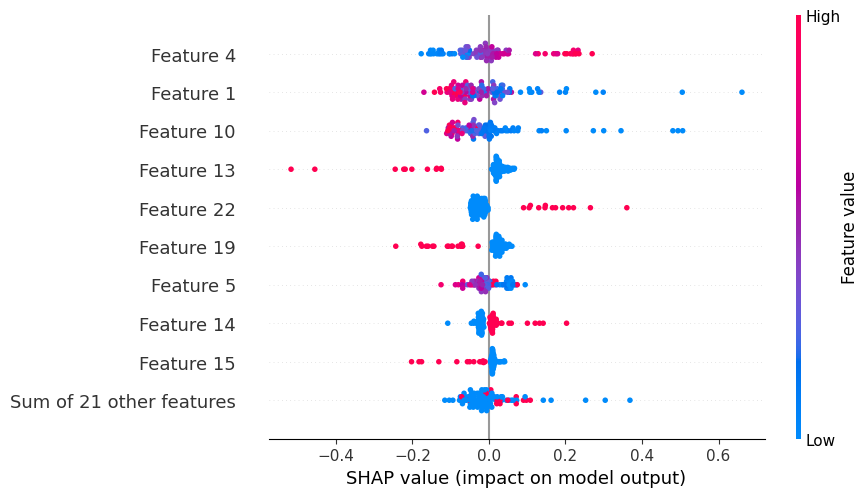

In [4]:
import shap

sample = X_test_processed[:100] # ilk 100 veriyi örenk oarla alıyoruz

if hasattr(sample, "toarray"):
    sample = sample.toarray() 

explainer = shap.PermutationExplainer(best_model.predict_proba, sample) # shap analizi 
shap_values = explainer(sample)

shap.plots.beeswarm(shap_values[:, :, 1])

In [6]:
cat_feature_names = list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + cat_feature_names


In [7]:

shap_values_class1 = shap_values[:, :, 1]
shap_values_class1.feature_names = all_feature_names




## Leakage Kontrolü -> loan_grade payı

In [12]:
shap_importance = np.abs(shap_values[:, :, 1].values).mean(axis=0)

loan_grade = sum(
    value for value, name in zip(shap_importance, all_feature_names)
    if "loan_grade" in name
)

print(f"loan_grade'in toplam SHAP önemine oranı: %{loan_grade / sum(shap_importance) * 100:.1f}")

loan_grade'in toplam SHAP önemine oranı: %14.6


## Tek Bir Kişi İçin Açıklama

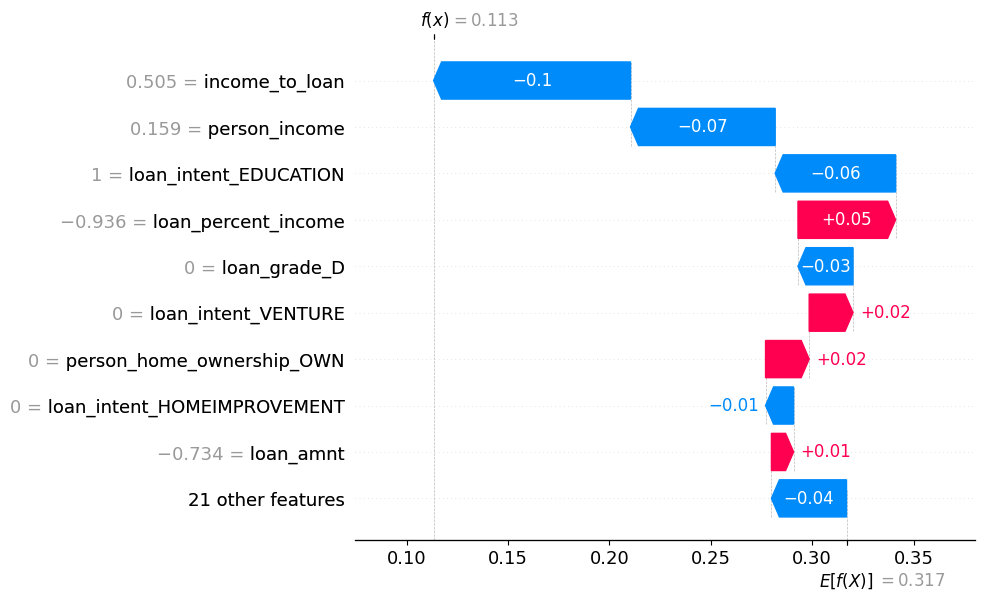

In [10]:
idx = 0
shap.plots.waterfall(shap_values_class1[idx])